In [17]:
###define file paths

from pathlib import Path

MAIN   = Path("/Users/albertoornaghi/Documents/GitHub/master_thesis")
CODE   = MAIN / "Code"
FIG    = MAIN / "Fig"
TAB    = MAIN / "Tab"

In [16]:
###import necessary libraries

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import root
from itertools import product
from scipy.stats import qmc


In [59]:
###set up an intial simulation to solve the system

##fix parameters at specific values satisfying restrictions

params = {
    'N':           4.0,
    'gamma':       1.0,
    'eps_L':       0,
    'eps_R':       0,
    'psi':         1.0,
}

params['eps_hat']   = (params['eps_L']**2) + (params['eps_R']**2)
params['beta']      = (params['psi']**2) / (params['N'] * params['gamma'])
params['eps_tilde'] = params['eps_L']**2 + 7 * (params['eps_R']**2)

##define system - the two equations are FOCs

def system(x, p):
    p_L, p_R = x
    return [
        
    3*p['beta']*p['eps_hat']*(p_L**5) + \
        
    (p_L**4)*(p['beta'])*(-3*(p['eps_hat']*p_R + 0.25*p['eps_tilde']) - p['eps_hat']*2*p_R) + \
        
    (p_L**3)*(4*p['psi'] + p['beta']*(-3*(p['eps_hat']*(p_R**2) - 0.5*p_R*p['eps_tilde']) +
    2*p_R*(p['eps_hat']*p_R + 0.25*p['eps_tilde']) - p['eps_hat']*(p_R**2))) + \
        
    (p_L**2)*((-3)*p['psi'] + p['beta']*((-0.75)*(p_R**2)*p['eps_tilde'] + 2*p_R*(p['eps_hat']*(p_R**2) - 0.5*p_R*p['eps_tilde'])
    + (p_R**2)*(p['eps_hat']*p_R + 0.25*p['eps_tilde']) + 3*p['eps_hat']*(p_R**3))) + \
        
    p_L*(-1 + p['psi']*2*p_R*(1-2*p_R) + p['beta']*(0.5*(p_R**3)*p['eps_tilde'] + 
    (p_R**2)*(p['eps_hat']*p_R**2 - 0.5*p_R*p['eps_tilde']) - 2*p['eps_hat']*(p_R**4))) + \
        
    (p_R**2)*(p['psi'] + 0.25*p['beta']*(p_R**2)*p['eps_tilde'] - p['eps_hat']*p['beta']*(p_R**3))

    , 
        
    3*p['beta']*p['eps_hat']*(p_R**5) + \
        
    (p_R**4)*(p['beta'])*(-3*(p['eps_hat']*p_L + 0.25*p['eps_tilde']) - p['eps_hat']*(2*p_L + 4)) + \
        
    (p_R**3)*(4*p['psi'] + p['beta']*(3*(-p['eps_hat']*(p_L**2) + 0.5*p_L*p['eps_tilde']) +
    (2*p_L + 4)*(p['eps_hat']*p_L + 0.25*p['eps_tilde']) + p['eps_hat']*p_L*(4 - p_L))) + \
        
    (p_R**2)*((-9)*p['psi'] + p['beta']*(3*(p['eps_hat']*(p_L**3) - 0.25*(p_L**2)*p['eps_tilde']) 
    + (2*p_L + 4)*(p['eps_hat']*(p_L**2) - 0.5*p_L*p['eps_tilde']) + p_L*(-p['eps_hat']*p_L - 0.25*p['eps_tilde'])*(4 - p_L))) + \
        
    p_R*(-1 - p['psi']*(4*(p_L**2) - 6*p_L - 4) + p['beta']*((0.25*(p_L**2)*p['eps_tilde'] - p['eps_hat']*(p_L**3))*(2*p_L + 4)
    + p_L*(-p['eps_hat']*(p_L**2) + 0.5*p_L*p['eps_tilde'])*(4 - p_L))) + \
        
    p_L*(p['psi']*(3*p_L - 4) + p['beta']*((p_L**3)*p['eps_hat'] - 0.25*(p_L**2)*p['eps_tilde'])*(4 - p_L)) + 1
    
    ]

##solve systems
sol = root(system, [0.25, 0.75], args=(params,), tol=1e-12)
p_L, p_R = sol.x

##compute pi_L and pi_R from the solution

pi_L = (params['psi'] / (params['N'] * params['gamma'])) * ((p_R - p_L)**2) * params['eps_L']*(p_L + p_R - 1/4)
pi_R = (params['psi'] / (params['N'] * params['gamma'])) * ((p_R - p_L)**2) * params['eps_R']*(7/4 - p_L - p_R)
net_pi_L = params['eps_L']*pi_L - params['eps_R']*pi_R

print(f"p_L  = {p_L:.10f}")
print(f"p_R  = {p_R:.10f}")
print(f"pi_L = {pi_L:.10f}")
print(f"pi_R = {pi_R:.10f}")

p_L  = 0.2500000000
p_R  = 0.7500000000
pi_L = 0.0000000000
pi_R = 0.0000000000


In [30]:
###iteratively solve over different starting values for robustness

##create list to contain solutions

solutions = []

##define grid of starting points and solve iteratively
##retain the same parameter values as cell above

for pL0, pR0 in product(np.linspace(0.05, 0.45, 5), 
                         np.linspace(0.55, 0.95, 5)):
    sol = root(system, [pL0, pR0], args=(params,), method='hybr', tol=1e-12)
    if sol.success and 0 < sol.x[0] < 0.5 and 0.5 < sol.x[1] < 1.0:
        solutions.append(sol.x)

##print solutions and check if the are all the same
##should all be the same point
solutions = np.array(solutions)
print("All solutions agree:", np.allclose(solutions, solutions[0], atol=1e-12))
print("p_L* =", solutions[0, 0], "  p_R* =", solutions[0, 1]) 


All solutions agree: True
p_L* = 0.24999999999999997   p_R* = 0.75


In [31]:
###verify that solutions hold over all parameter space for robustness

##define valid parameter bounds

bounds = {
    'N':       (4, 1000),
    'gamma':   (1, 100),
    'eps_L':   (0.01, 2),
    'eps_R':   (0.01, 2),
    'psi':     (1, 100),
}

##define analytic restriction from existence, uniqueness proof

def satisfies_restrictions(N, gamma, eps_L, eps_R, psi):

    return abs(eps_L - eps_R) <= (4 * N * gamma) / (3 * psi * (eps_L + eps_R))
    
    return True  


##use latin hypercube sampling to obtain specific parameter values
##for each iteration

sampler = qmc.LatinHypercube(d=len(bounds))
samples = sampler.random(n=100000)
samples = qmc.scale(samples,
                    [b[0] for b in bounds.values()],
                    [b[1] for b in bounds.values()])

##create lists to contain results of iteration

results = []
failures = []

##iteratively define parameters and solve for each sample of parameters

for sample in samples:
    N, gamma, eps_L, eps_R, psi = sample

    ##check that analytic restriction holds
    if not satisfies_restrictions(N, gamma, eps_L, eps_R, psi):
        continue

    ##define parameters according to sample
    p = {
        'N':         N,
        'gamma':     gamma,
        'eps_L':     eps_L,
        'eps_R':     eps_R,
        'psi':       psi,
        'eps_hat':   eps_L**2 + eps_R**2,
        'beta':      psi**2 / (N * gamma),
        'eps_tilde': eps_L**2 + 7 * eps_R**2,
    }

    ##solve
    sol = root(system, [0.25, 0.75], args=(p,), tol=1e-12)

    ##save solution as result if policies fall in the required bounds
    if sol.success:
        p_L, p_R = sol.x
        in_range = (0 <= p_L <= 0.5) and (0.5 <= p_R <= 1.0)
        results.append({
            'params': sample,
            'p_L': p_L,
            'p_R': p_R,
            'in_range': in_range,
        })

        ##save solution as fail if policies fall in the required bounds
        if not in_range:
            failures.append(results[-1])

    
##check solutions
print(f"Solved: {len(results)}")
print(f"Out of admissible range: {len(failures)}")
if failures:
    for f in failures[:10]:
        print(f"  p_L={f['p_L']:.6f}, p_R={f['p_R']:.6f}, params={f['params']}")

Solved: 99883
Out of admissible range: 0


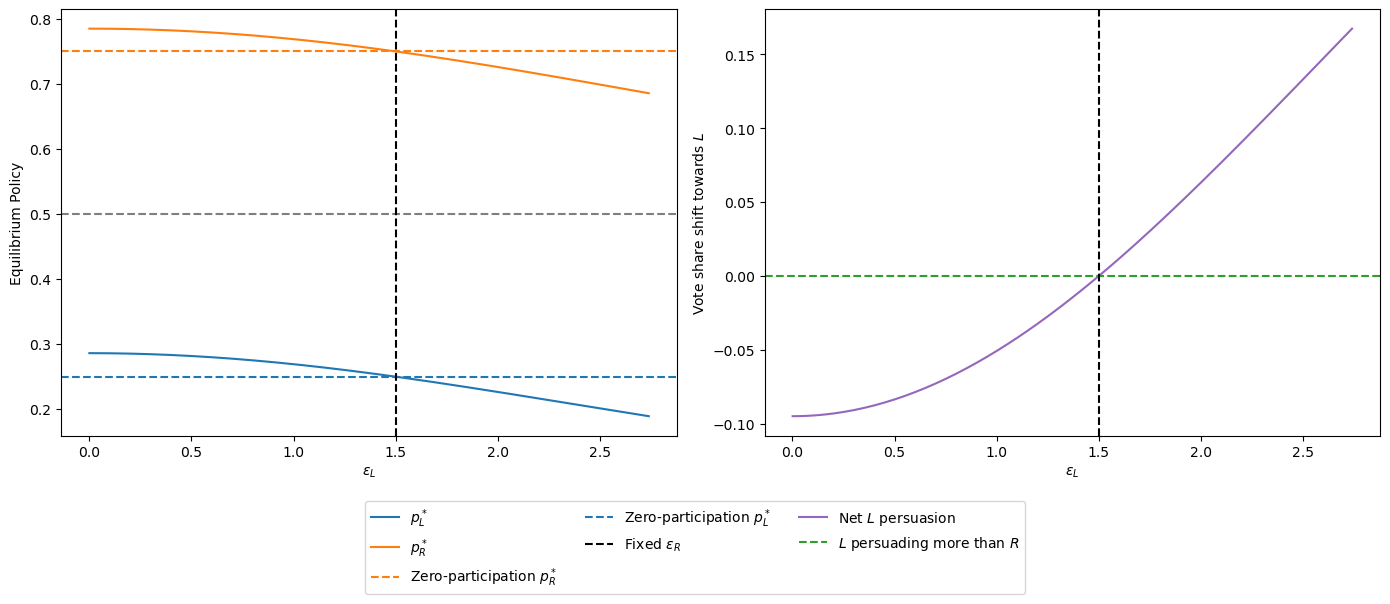

In [99]:
###main comparative statics on participation persuasiveness

##define parameters s.t. L's persuasiveness varies

params = {
    'N':           4.0,
    'gamma':       1.0,
    'eps_R':       1.5,
    'psi':         1.0,
}
params['beta'] = (params['psi']**2) / (params['N'] * params['gamma'])


##parameter restriction check

def satisfies_restrictions(eps_L, params):
    eps_R = params['eps_R']
    N = params['N']
    gamma = params['gamma']
    psi = params['psi']
    return abs(eps_L - eps_R) <= (4 * N * gamma) / (3 * psi * (eps_L + eps_R))

##define grid for L persuasiveness

eps_L_grid = np.linspace(0.001, 10.0, 600)
results = []
results_participation = []
valid_eps_L = []

##define initial values

x_prev = [0.25, 0.75]
default_guess = [0.25, 0.75]

##solve repeatedly for each value in L persuasiveness grid

for eps_L in eps_L_grid:
    
    #skip if parameter restriction violated
    if not satisfies_restrictions(eps_L, params):
        continue

    ##define composite parameters
    params['eps_L']     = eps_L
    params['eps_hat']   = eps_L**2 + params['eps_R']**2
    params['eps_tilde'] = eps_L**2 + 7 * params['eps_R']**2

    ##solve and save admissible solutions
    sol = root(system, x_prev, args=(params,), method='hybr', tol=1e-12)
    p_L, p_R = sol.x
    in_range = sol.success and (0 <= p_L <= 0.5) and (0.5 <= p_R <= 1.0)

    ##calculate participation and net participation
    pi_L = (params['psi'] / (params['N'] * params['gamma'])) * ((p_R - p_L)**2) * params['eps_L']*(p_L + p_R - 1/4)
    pi_R = (params['psi'] / (params['N'] * params['gamma'])) * ((p_R - p_L)**2) * params['eps_R']*(7/4 - p_L - p_R)
    net_pi_L = params['eps_L']*pi_L - params['eps_R']*pi_R

    ##for good solutions, use them as the starting value
    if in_range:
        results.append(sol.x)
        results_participation.append([net_pi_L])
        valid_eps_L.append(eps_L)
        x_prev = sol.x  ##only warm-start from good solutions
    else:
        x_prev = default_guess  ##reset to avoid cascading failures



##plot and format - two separate plots

results = np.array(results)
results_participation = np.array(results_participation)
valid_eps_L = np.array(valid_eps_L)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#left panel for policy plot
ax1.plot(valid_eps_L, results[:, 0], label=r'$p_L^*$')
ax1.plot(valid_eps_L, results[:, 1], label=r'$p_R^*$')
ax1.axhline(y=0.5, color='tab:gray', linestyle='--')
ax1.axhline(y=0.75, color='tab:orange', linestyle='--', label='Zero-participation ' r'$p_R^*$')
ax1.axhline(y=0.25, color='tab:blue', linestyle='--', label='Zero-participation ' r'$p_L^*$')
ax1.axvline(x=1.5, color='black', linestyle='--', label='Fixed ' r'$\varepsilon_R$')
ax1.set_xlabel(r'$\varepsilon_L$')
ax1.set_ylabel('Equilibrium Policy')


#right panel for participation plot
ax2.plot(valid_eps_L, results_participation[:, 0], color = 'tab:purple', label=r'Net $L$ persuasion')
ax2.set_xlabel(r'$\varepsilon_L$')
ax2.axhline(y=0, color='tab:green', linestyle='--', label = r'$L$ persuading more than $R$')
ax2.axvline(x=1.5, color='black', linestyle='--')
ax2.set_ylabel(r'Vote share shift towards $L$')


fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3)
plt.tight_layout()
plt.savefig(FIG / 'cs_eps_L.jpg', dpi=300, bbox_inches='tight')
plt.show()

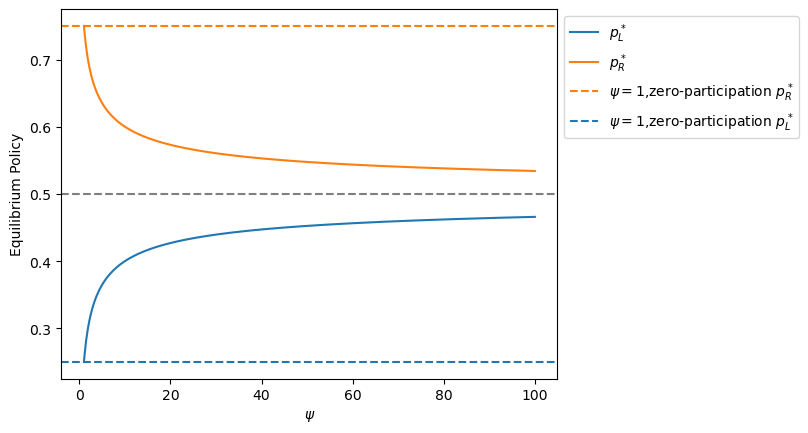

In [33]:
###CS on psi with zero participation

##define parameters
params = {
    'N':           4.0,
    'gamma':       1.0,
    'eps_R':       0.0000000000000000000000001,
    'eps_L':       0.0000000000000000000000001,
}
params['eps_hat']   = params['eps_L']**2 + params['eps_R']**2
params['eps_tilde'] = params['eps_L']**2 + 7 * params['eps_R']**2


##parameter restriction check
def satisfies_restrictions(psi, params):
    eps_R = params['eps_R']
    eps_L = params['eps_L']
    N = params['N']
    gamma = params['gamma']
    return abs(eps_L - eps_R) <= (4 * N * gamma) / (3 * psi * (eps_L + eps_R))

##define grid
psi_grid = np.linspace(1, 100.0, 600)
results_psi1 = []
valid_psi1 = []
x_prev = [0.25, 0.75]
default_guess = [0.25, 0.75]

##solve repeatedly for each value of psi

for psi in psi_grid:
    if not satisfies_restrictions(psi, params):
        continue

    params['psi']  = psi
    params['beta'] = psi**2 / (params['N'] * params['gamma'])

    sol = root(system, x_prev, args=(params,), method='hybr', tol=1e-12)
    p_L, p_R = sol.x
    in_range = sol.success and (0 <= p_L <= 0.5) and (0.5 <= p_R <= 1.0)

    if in_range:
        results_psi1.append(sol.x)
        valid_psi1.append(psi)
        x_prev = sol.x
    else:
        x_prev = default_guess

##plot
results_psi1 = np.array(results_psi1)
valid_psi1 = np.array(valid_psi1)
plt.plot(valid_psi1, results_psi1[:, 0], label=r'$p_L^*$')
plt.plot(valid_psi1, results_psi1[:, 1], label=r'$p_R^*$')
plt.xlabel(r'$\psi$')
plt.ylabel('Equilibrium Policy')
plt.axhline(y=0.5, color='tab:gray', linestyle='--')
plt.axhline(y=0.75, color='tab:orange', linestyle='--', label= r'$\psi=1$' ',' 'zero-participation ' r'$p_R^*$')
plt.axhline(y=0.25, color='tab:blue', linestyle='--', label= r'$\psi=1$' ',' 'zero-participation ' r'$p_L^*$')
plt.legend(bbox_to_anchor=(1, 1))
plt.savefig(FIG / 'cs_psi_nopart.jpg', dpi=300, bbox_inches='tight')
plt.show()

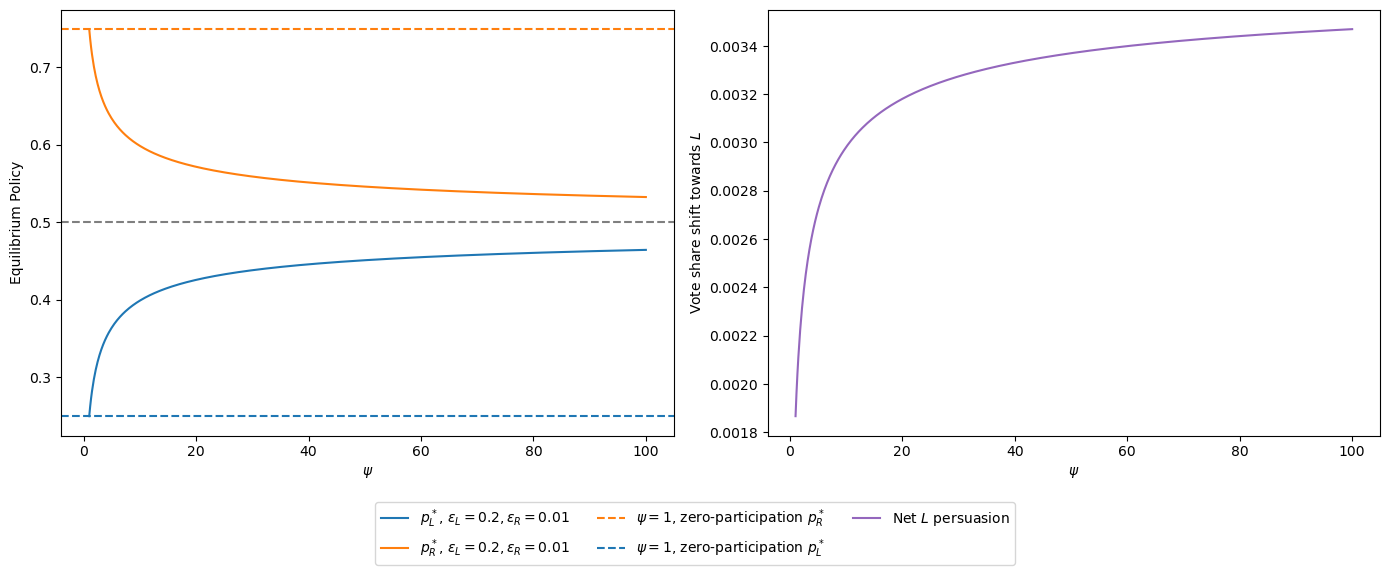

In [107]:
###CS on psi with non-zero participation

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

##define parameters
params = {
    'N':           4.0,
    'gamma':       1.0,
    'eps_R':       0.01,
    'eps_L':       0.20,
}
params['eps_hat']   = params['eps_L']**2 + params['eps_R']**2
params['eps_tilde'] = params['eps_L']**2 + 7 * params['eps_R']**2



##parameter restriction check
def satisfies_restrictions(psi, params):
    eps_R = params['eps_R']
    eps_L = params['eps_L']
    N = params['N']
    gamma = params['gamma']
    return eps_L - eps_R <= (4 * N * gamma) / (3 * psi * (eps_L + eps_R))

##list to save results
psi_grid = np.linspace(1, 100.0, 600)
results_psi2 = []
valid_psi2 = []
results_pi_psi2 = []
x_prev = [0.25, 0.75]

##solve repeatedly for each value of psi

for psi in psi_grid: 
    if not satisfies_restrictions(psi, params): 
        continue

    params['psi']  = psi
    params['beta'] = psi**2 / (params['N'] * params['gamma'])

    sol = root(system, x_prev, args=(params,), method='hybr', tol=1e-12)
    p_L, p_R = sol.x
    in_range = sol.success and (0 <= p_L <= 0.5) and (0.5 <= p_R <= 1.0)

    ##calculate participation and net participation
    pi_L = (params['psi'] / (params['N'] * params['gamma'])) * ((p_R - p_L)**2) * params['eps_L']*(p_L + p_R - 1/4)
    pi_R = (params['psi'] / (params['N'] * params['gamma'])) * ((p_R - p_L)**2) * params['eps_R']*(7/4 - p_L - p_R)
    net_pi_L = params['eps_L']*pi_L - params['eps_R']*pi_R
    
    if in_range:
        results_psi2.append(sol.x)
        valid_psi2.append(psi)
        results_pi_psi2.append(net_pi_L)
        x_prev = sol.x
    else:
        x_prev = default_guess

##plot and format - two separate plots

results_psi2 = np.array(results_psi2)
results_pi_psi2 = np.array(results_pi_psi2)
valid_psi2 = np.array(valid_psi2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#left panel for policy plot
ax1.plot(valid_psi2, results_psi2[:, 0], label=r'$p_L^*$' ', ' r'$\varepsilon_L = 0.2,\varepsilon_R = 0.01$')
ax1.plot(valid_psi2, results_psi2[:, 1], label=r'$p_R^*$' ', ' r'$\varepsilon_L = 0.2,\varepsilon_R = 0.01$')
ax1.set_xlabel(r'$\psi$')
ax1.set_ylabel('Equilibrium Policy')
ax1.axhline(y=0.5, color='tab:gray', linestyle='--')
ax1.axhline(y=0.75, color='tab:orange', linestyle='--', label= r'$\psi=1$' ',' ' zero-participation ' r'$p_R^*$')
ax1.axhline(y=0.25, color='tab:blue', linestyle='--', label= r'$\psi=1$' ',' ' zero-participation ' r'$p_L^*$')


#right panel for participation plot
ax2.plot(valid_psi2, results_pi_psi2, color = 'tab:purple',  label=r'Net $L$ persuasion')
ax2.set_xlabel(r'$\psi$')
ax2.set_ylabel(r'Vote share shift towards $L$')


fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3)
plt.tight_layout()
plt.savefig(FIG / 'cs_psi_part.jpg', dpi=300, bbox_inches='tight')
plt.show()



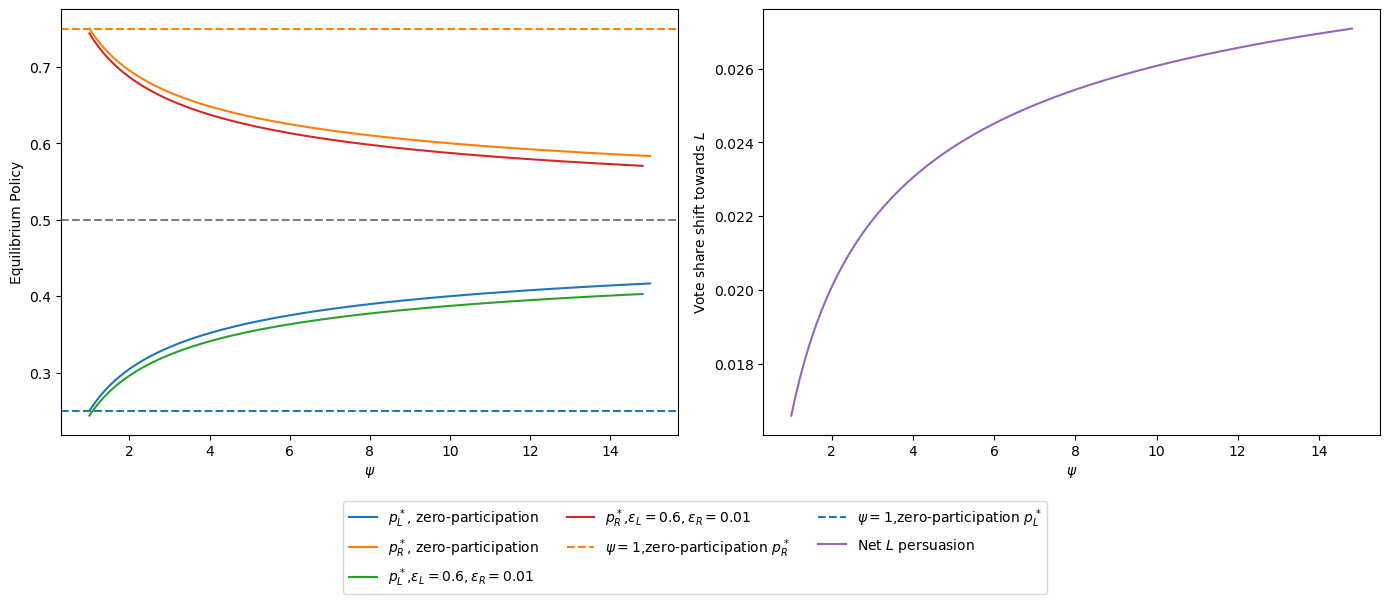

In [114]:
###Combine graphs for psi - with new bounds to show difference well

###CS on psi with zero participation

## Define parameters
params = {
    'N':           4.0,
    'gamma':       1.0,
    'eps_R':       0.0000000000000000000000001,
    'eps_L':       0.0000000000000000000000001,
}
params['eps_hat']   = params['eps_L']**2 + params['eps_R']**2
params['eps_tilde'] = params['eps_L']**2 + 7 * params['eps_R']**2



##parameter restriction check
def satisfies_restrictions(psi, params):
    eps_R = params['eps_R']
    eps_L = params['eps_L']
    N = params['N']
    gamma = params['gamma']
    return eps_L - eps_R <= (4 * N * gamma) / (3 * psi * (eps_L + eps_R))

##define lists to save results

results_psi3 = []
valid_psi3 = []
x_prev = [0.25, 0.75]

##redefine grid with new bounds to ensure results can be read well
##in both cases (w/non-zero participation many psi are inadmissible)

psi_grid = np.linspace(1, 15.0, 600)



for psi in psi_grid:
    if not satisfies_restrictions(psi, params):
        continue

    params['psi']  = psi
    params['beta'] = psi**2 / (params['N'] * params['gamma'])

    sol = root(system, x_prev, args=(params,), method='hybr', tol=1e-12)
    p_L, p_R = sol.x
    in_range = sol.success and (0 <= p_L <= 0.5) and (0.5 <= p_R <= 1.0)

    if in_range:
        results_psi3.append(sol.x)
        valid_psi3.append(psi)
        x_prev = sol.x
    else:
        x_prev = default_guess


###CS on psi with non-zero participation



##define parameters
params = {
    'N':           4.0,
    'gamma':       1.0,
    'eps_R':       0.01,
    'eps_L':       0.6,
}
params['eps_hat']   = params['eps_L']**2 + params['eps_R']**2
params['eps_tilde'] = params['eps_L']**2 + 7 * params['eps_R']**2


##parameter restriction check
def satisfies_restrictions(psi, params):
    eps_R = params['eps_R']
    eps_L = params['eps_L']
    N = params['N']
    gamma = params['gamma']
    return eps_L - eps_R <= (4 * N * gamma) / (3 * psi * (eps_L + eps_R))

##define lists to save results

results_psi4 = []
valid_psi4 = []
results_pi_psi4 = []
x_prev = [0.25, 0.75]


for psi in psi_grid: 
    if not satisfies_restrictions(psi, params):
        continue

    params['psi']  = psi
    params['beta'] = psi**2 / (params['N'] * params['gamma'])

    sol = root(system, x_prev, args=(params,), method='hybr', tol=1e-12)
    p_L, p_R = sol.x
    in_range = sol.success and (0 <= p_L <= 0.5) and (0.5 <= p_R <= 1.0)

    ##calculate participation and net participation
    pi_L = (params['psi'] / (params['N'] * params['gamma'])) * ((p_R - p_L)**2) * params['eps_L']*(p_L + p_R - 1/4)
    pi_R = (params['psi'] / (params['N'] * params['gamma'])) * ((p_R - p_L)**2) * params['eps_R']*(7/4 - p_L - p_R)
    net_pi_L = params['eps_L']*pi_L - params['eps_R']*pi_R

    if in_range:
        results_psi4.append(sol.x)
        valid_psi4.append(psi)
        results_pi_psi4.append(net_pi_L)
        x_prev = sol.x
    else:
        x_prev = default_guess



##plot and format - two separate plots

results_psi3 = np.array(results_psi3)
valid_psi3 = np.array(valid_psi3)
results_psi4 = np.array(results_psi4)
valid_psi4 = np.array(valid_psi4)
results_pi_psi4 = np.array(results_pi_psi4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

##left panel for policy plot
ax1.plot(valid_psi3, results_psi3[:, 0], label=r'$p_L^*$' ', zero-participation' )
ax1.plot(valid_psi3, results_psi3[:, 1], label=r'$p_R^*$' ', zero-participation') ##no participation case

ax1.plot(valid_psi4, results_psi4[:, 0], label=r'$p_L^*$' ',' r'$\varepsilon_L = 0.6, \varepsilon_R = 0.01$')
ax1.plot(valid_psi4, results_psi4[:, 1], label=r'$p_R^*$' ',' r'$\varepsilon_L = 0.6, \varepsilon_R = 0.01$') ##participation case

ax1.set_xlabel(r'$\psi$')
ax1.set_ylabel('Equilibrium Policy')
ax1.axhline(y=0.5, color='tab:gray', linestyle='--')
ax1.axhline(y=0.75, color='tab:orange', linestyle='--', label= r'$\psi=1$' ',' 'zero-participation ' r'$p_R^*$')
ax1.axhline(y=0.25, color='tab:blue', linestyle='--', label= r'$\psi=1$' ',' 'zero-participation ' r'$p_L^*$')

##right panel for participation plot
ax2.plot(valid_psi4, results_pi_psi4, color = 'tab:purple',  label=r'Net $L$ persuasion')
ax2.set_xlabel(r'$\psi$')
ax2.set_ylabel(r'Vote share shift towards $L$')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3)
plt.tight_layout()
plt.savefig(FIG / 'cs_psi_combined.jpg', dpi=300, bbox_inches='tight')
plt.show()


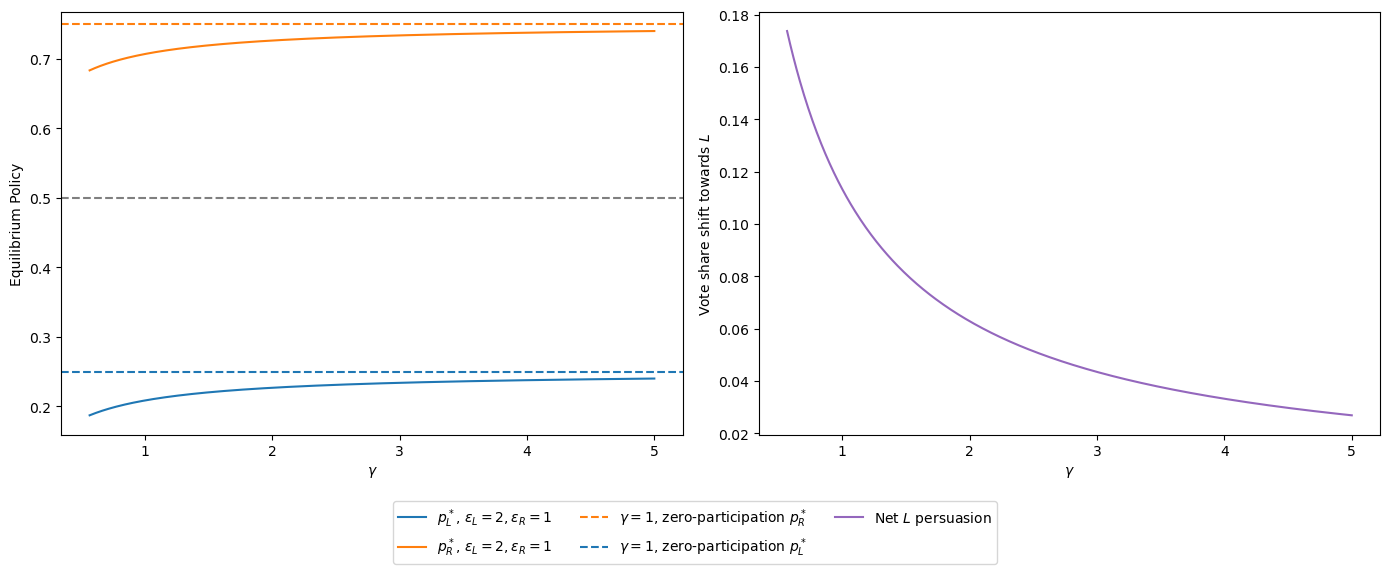

In [113]:
###CS on gamma

###CAREFUL: THERE IS SOMETHING WRONG HERE - CHECK CAREFULLY!!!

##define parameters
params = {
    'N':           4.0,
    'psi':       1.0,
    'eps_R':       1,
    'eps_L':       2,
}

params['eps_hat']   = params['eps_L']**2 + params['eps_R']**2
params['eps_tilde'] = params['eps_L']**2 + 7 * params['eps_R']**2


##parameter restriction check
def satisfies_restrictions(gamma, params):
    eps_R = params['eps_R']
    eps_L = params['eps_L']
    N = params['N']
    psi = params['psi']
    return eps_L - eps_R <= (4 * N * gamma) / (3 * psi * (eps_L + eps_R))

##define grid
gamma_grid = np.linspace(0.0001, 5.0, 600)
results_gamma = []
valid_gamma = []
results_pi_gamma = []
x_prev = [0.25, 0.75]
default_guess = [0.25, 0.75]

for gamma in gamma_grid: ##SOMETHING WRONG HERE!!!!
    if not satisfies_restrictions(gamma, params):
        continue

    params['gamma']  = gamma
    params['beta'] = params['psi']**2 / (params['N'] * params['gamma'])

    sol = root(system, x_prev, args=(params,), method='hybr', tol=1e-12)
    p_L, p_R = sol.x
    in_range = sol.success and (0 <= p_L <= 0.5) and (0.5 <= p_R <= 1.0)

    ##calculate participation and net participation
    pi_L = (params['psi'] / (params['N'] * params['gamma'])) * ((p_R - p_L)**2) * params['eps_L']*(p_L + p_R - 1/4)
    pi_R = (params['psi'] / (params['N'] * params['gamma'])) * ((p_R - p_L)**2) * params['eps_R']*(7/4 - p_L - p_R)
    net_pi_L = params['eps_L']*pi_L - params['eps_R']*pi_R

    if in_range:
        results_gamma.append(sol.x)
        valid_gamma.append(gamma)
        results_pi_gamma.append(net_pi_L)
        x_prev = sol.x
    else:
        x_prev = default_guess

##plot and format - with separate panels
results_gamma = np.array(results_gamma)
valid_gamma = np.array(valid_gamma)
results_pi_gamma = np.array(results_pi_gamma)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

##left panel for policy
ax1.plot(valid_gamma, results_gamma[:, 0], label=r'$p_L^*$' ', ' r'$\varepsilon_L = 2,\varepsilon_R = 1$')
ax1.plot(valid_gamma, results_gamma[:, 1], label=r'$p_R^*$' ', ' r'$\varepsilon_L = 2,\varepsilon_R = 1$')
ax1.set_xlabel(r'$\gamma$')
ax1.set_ylabel('Equilibrium Policy')
ax1.axhline(y=0.5, color='tab:gray', linestyle='--')
ax1.axhline(y=0.75, color='tab:orange', linestyle='--', label= r'$\gamma=1$' ',' ' zero-participation ' r'$p_R^*$')
ax1.axhline(y=0.25, color='tab:blue', linestyle='--', label= r'$\gamma=1$' ',' ' zero-participation ' r'$p_L^*$')

##right panel for participation

ax2.plot(valid_gamma, results_pi_gamma, color = 'tab:purple',  label=r'Net $L$ persuasion')
ax2.set_xlabel(r'$\gamma$')
ax2.set_ylabel(r'Vote share shift towards $L$')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3)
plt.tight_layout()
plt.savefig(FIG / 'cs_gamma.jpg', dpi=300, bbox_inches='tight')
plt.show()